# Contraction Hierarchies Shortcut Analysis

Full exploratory analysis of your CH shortcut table (Parquet format).

Works with the table generated by `generate_test_data.py` or your real production data.

Expected columns:
- `incoming_edge`
- `outgoing_edge`
- `cost`
- `via_edge`      (only for unpacking)
- `via_cell`      (partition id)
- `inside`        (+1 = upward, 0 = same level, -1 = downward)

In [2]:
#!pip install -q pyarrow pandas matplotlib seaborn plotly
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
# ←←←←← CHANGE THIS PATH TO YOUR FILE ←←←←←
#PARQUET_PATH = "../data/ch_shortcuts.parquet"
edges_PATH = "../../spark-shortest-path/data/Burnaby_driving_simplified_edges_with_h3.csv"
#shortcuts_df = spark.read.parquet(PARQUET_PATH)
edges = pd.read_csv(edges_PATH)
edges_df = edges.set_index('id')
print(f"Loaded {len(edges):,} all edges")
edges.head()

Loaded 34,965 all edges


,length,maxspeed,geometry,highway,cost,incoming_cell,outgoing_cell,lca_res,id
0,98.503,30.0,LINESTRING (-122.92154693603516 49.27764129638...,tertiary_link,11.82036,644733695069033029,644733695069283890,8,0
1,53.933,30.0,LINESTRING (-122.92154693603516 49.27764129638...,tertiary,6.47196,644733695069345412,644733695069283890,9,1
2,684.050,50.0,LINESTRING (-122.92154693603516 49.27764129638...,tertiary,49.25160,644733695063774494,644733695069283890,7,2
3,35.488,30.0,LINESTRING (-122.92096710205078 49.27793121337...,tertiary,4.25856,644733695069337920,644733695069345412,10,3
4,53.933,30.0,LINESTRING (-122.92096710205078 49.27793121337...,tertiary,6.47196,644733695069283890,644733695069345412,9,4


In [ ]:
# ←←←←← CHANGE THIS PATH TO YOUR FILE ←←←←←
#PARQUET_PATH = "../data/ch_shortcuts.parquet"
PARQUET_PATH = "../../spark-shortest-path/output/Burnaby_shortcuts_final"
#shortcuts_df = spark.read.parquet(PARQUET_PATH)
df = pd.read_parquet(PARQUET_PATH)

# Ensure integer types for IDs and flags
df['incoming_edge'] = df['incoming_edge'].astype(int)
df['outgoing_edge'] = df['outgoing_edge'].astype(int)
df['via_edge'] = df['via_edge'].fillna(0).astype(int)
df['inside'] = df['inside'].astype(int)
df['cost'] = df['cost'].astype(float) # Cost might be float

print(f"Loaded {len(df):,} shortcut edges")
df.head()

In [ ]:
# ←←←←← CHANGE THIS PATH TO YOUR FILE ←←←←←
#PARQUET_PATH = "../data/ch_shortcuts.parquet"
PARQUET_PATH = "../../spark-shortest-path/output/Burnaby_shortcuts_final"
#shortcuts_df = spark.read.parquet(PARQUET_PATH)
df = pd.read_parquet(PARQUET_PATH)

# Ensure integer types for IDs and flags
df['incoming_edge'] = df['incoming_edge'].astype(int)
df['outgoing_edge'] = df['outgoing_edge'].astype(int)
df['via_edge'] = df['via_edge'].fillna(0).astype(int)
df['inside'] = df['inside'].astype(int)
df['cost'] = df['cost'].astype(float) # Cost might be float

print(f"Loaded {len(df):,} shortcut edges")
df.head()

Loaded 2,273,221 shortcut edges


,incoming_edge,outgoing_edge,cost,via_edge,inside,cell
0,19,1128,17.858967,19,0,608704929887944703
1,30,16904,61.799682,26838,0,608704897809907711
2,46,7747,39.198300,46,1,608704929871167487
3,46,9134,34.085300,46,0,608704929871167487
4,57,9152,57.419547,57,0,608704929871167487


In [3]:
len(df)

213493

## 1. Basic Statistics

In [5]:
print("=== Data types ===")
print(df.dtypes)
print(f"\nUnique incoming edges  : {df['incoming_edge'].nunique():,}")
print(f"Unique outgoing edges : {df['outgoing_edge'].nunique():,}")
print(f"Total shortcuts       : {len(df):,}")
print(f"Average out-degree    : {len(df) / df['incoming_edge'].nunique():.2f}")

=== Data types ===
incoming_edge      int32
outgoing_edge      int32
cost             float64
via_edge           int32
inside              int8
cell               int64
dtype: object

Unique incoming edges  : 5,895
Unique outgoing edges : 5,898
Total shortcuts       : 213,493
Average out-degree    : 36.22


## 2. Hierarchy Direction (`inside` flag)

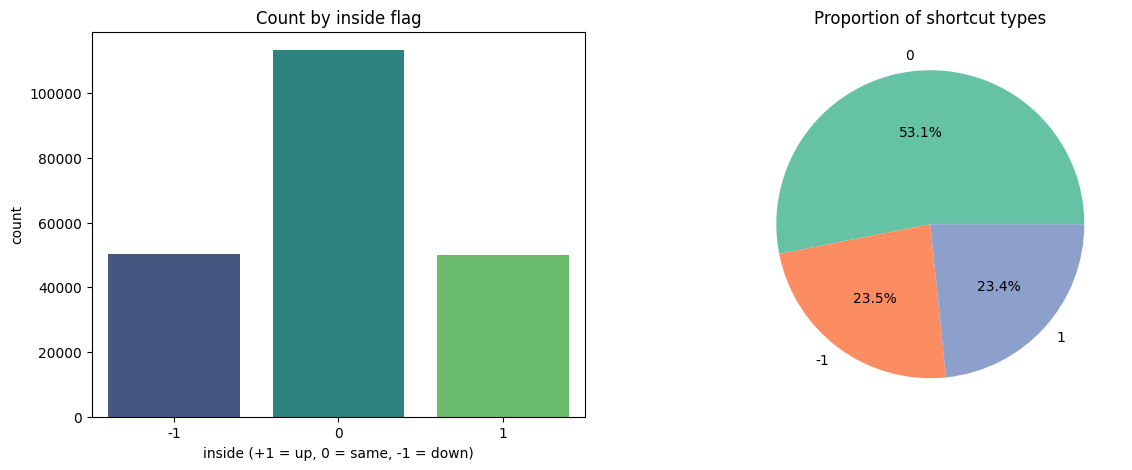

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

sns.countplot(data=df, x='inside', palette='viridis', ax=ax[0])
ax[0].set_title('Count by inside flag')
ax[0].set_xlabel('inside (+1 = up, 0 = same, -1 = down)')

df['inside'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[1], colors=['#66c2a5','#fc8d62','#8da0cb'])
ax[1].set_title('Proportion of shortcut types')
ax[1].set_ylabel('')

plt.show()

## 3. Cost Distribution

In [7]:
fig = px.histogram(df, x='cost', nbins=100, marginal="rug",
                   title="Shortcut Cost Distribution",
                   labels={'cost': 'Cost (weight)'},
                   color='inside',
                   color_discrete_sequence=['#1f77b4','#ff7f0e','#2ca02c'])
fig.update_layout(bargap=0.1)
fig.show()

In [8]:
print(df['cost'].describe(percentiles=[.25,.50,.75,.90,.95,.99]))

count    213493.000000
mean         28.472696
std          27.761771
min           0.045675
25%           7.367067
50%          18.755157
75%          42.811981
90%          67.220797
95%          83.451472
99%         120.525970
max         215.581938
Name: cost, dtype: float64


## 4. Top Edges by Number of Shortcuts

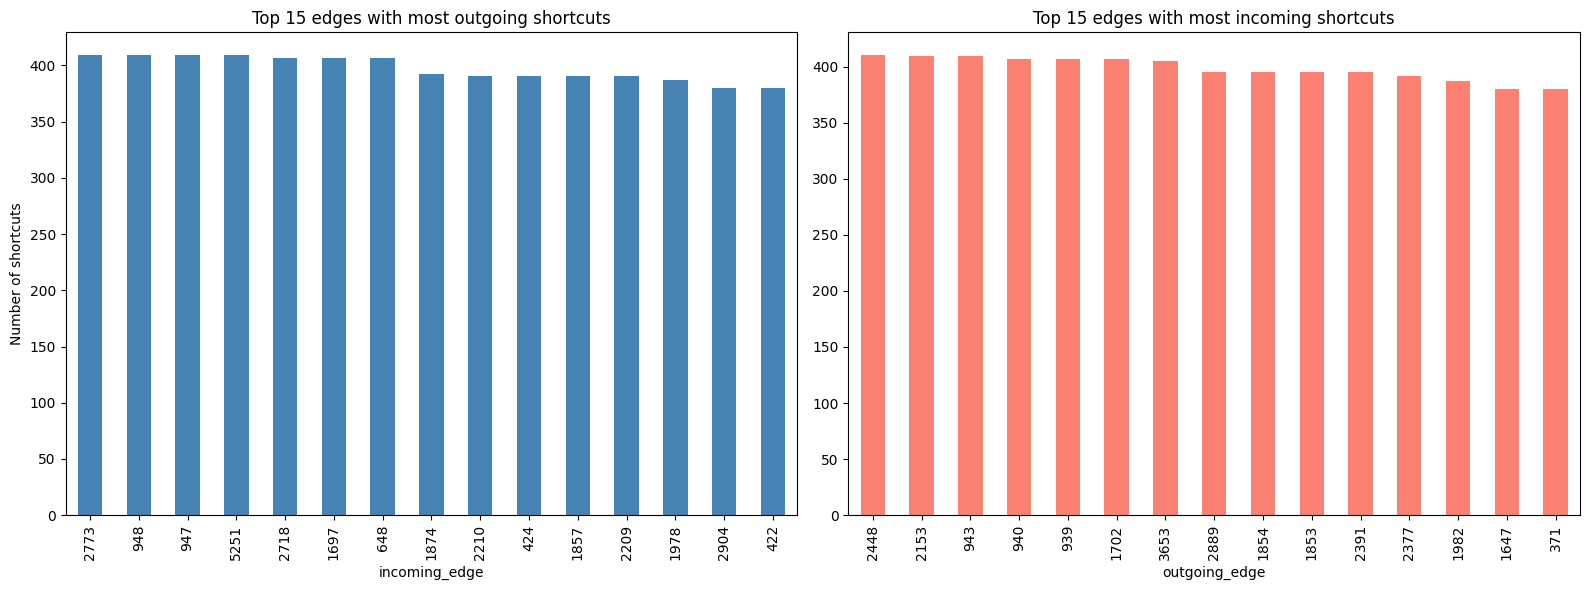

In [9]:
top_in  = df['incoming_edge'].value_counts().head(15)
top_out = df['outgoing_edge'].value_counts().head(15)

fig, ax = plt.subplots(1,2,figsize=(16,6))
top_in.plot.bar(ax=ax[0], color='steelblue')
ax[0].set_title('Top 15 edges with most outgoing shortcuts')
ax[0].set_ylabel('Number of shortcuts')

top_out.plot.bar(ax=ax[1], color='salmon')
ax[1].set_title('Top 15 edges with most incoming shortcuts')
plt.tight_layout()
plt.show()

## 5. Partitioning Quality (`cell`)

In [13]:
cell_counts = df['cell'].value_counts().sort_index()

fig = px.bar(x=cell_counts.index, y=cell_counts.values,
             labels={'x':'Cell ID', 'y':'Number of shortcuts'},
             title='Shortcuts per Partition Cell')
fig.show()

print(f"Used cells       : {df['cell'].nunique()}")
print(f"Most loaded cell : {cell_counts.max():,} shortcuts")

Used cells       : 1102
Most loaded cell : 34,176 shortcuts


## 6. Sample Shortcut Chain (sanity-check for unpacking)

In [19]:
start_edge = df['incoming_edge'].sample(1).iloc[0]
print(f"Following upward shortcuts starting from edge {start_edge}")

chain = []
current = start_edge
for _ in range(20):
    candidates = df[(df['incoming_edge'] == current) & (df['inside'] >= 0)]
    if len(candidates) == 0:
        break
    row = candidates.sample(1).iloc[0]
    chain.append({
        'from': current,
        'to': row['outgoing_edge'],
        'cost': row['cost'],
        'via_edge': row['via_edge'],
        'inside': row['inside'],
        'cell': row['cell']
    })
    current = row['outgoing_edge']

pd.DataFrame(chain)

Following upward shortcuts starting from edge 1827


,from,to,cost,via_edge,inside,cell
0,1827.0,2518.0,8.842300,1827.0,0.0,6.136998e+17
1,2518.0,401.0,24.170383,2518.0,0.0,6.136998e+17
2,401.0,400.0,7.009200,401.0,0.0,6.136998e+17
3,400.0,401.0,6.108067,400.0,0.0,6.136998e+17
4,401.0,815.0,12.588400,401.0,0.0,6.136998e+17
5,815.0,1017.0,14.158933,815.0,1.0,6.136998e+17
6,1017.0,1914.0,51.531433,1017.0,1.0,6.091962e+17
7,1914.0,2209.0,51.194767,1914.0,1.0,6.046926e+17
8,2209.0,3773.0,67.312365,2209.0,0.0,0.000000e+00
9,3773.0,4774.0,56.531095,3773.0,0.0,0.000000e+00


## 7. Estimated Memory Usage in C++ Router

In [20]:
bytes_per_shortcut = 16   # our packed struct
gb_shortcuts = len(df) * bytes_per_shortcut / (1024**3)
gb_index     = len(df) * 4 / (1024**3)   # 4-byte indices

print(f"Shortcuts themselves : {gb_shortcuts:.2f} GB")
print(f"Adjacency index     : {gb_index:.2f} GB")
print(f"Total estimated RAM : {gb_shortcuts + gb_index:.2f} GB")

Shortcuts themselves : 0.00 GB
Adjacency index     : 0.00 GB
Total estimated RAM : 0.00 GB


Done! You now have a complete picture of your CH shortcut table.

When the numbers look good → run the C++ router from the previous repository and enjoy microsecond queries ✨

## 8. NetworkX Connectivity Analysis
Analyze the connectivity of the graph using NetworkX.


In [44]:
import networkx as nx

print("Building NetworkX graph...")
G = nx.DiGraph()
# Add edges from the dataframe
# df has 'incoming_edge', 'outgoing_edge', 'cost'
# We use the values directly to add weighted edges
G.add_weighted_edges_from(df[['incoming_edge', 'outgoing_edge', 'cost']].values)

print(f"NetworkX Graph built: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")


Building NetworkX graph...
NetworkX Graph built: 5,900 nodes, 213,493 edges
NetworkX Graph built: 5,900 nodes, 213,493 edges


In [47]:
G.is_directed()

True

In [54]:
print("Analyzing Connectivity...")

# Weakly Connected Components
wcc = list(nx.weakly_connected_components(G))
wcc_sizes = sorted([len(c) for c in wcc], reverse=True)
print(f"Number of Weakly Connected Components: {len(wcc):,}")
print(f"Size of largest WCC: {wcc_sizes[0]:,}")
print(f"Sizes of all WCCs: {wcc_sizes}")

# Strongly Connected Components
scc = list(nx.strongly_connected_components(G))
scc_sizes = sorted([len(c) for c in scc], reverse=True)
print(f"Number of Strongly Connected Components: {len(scc):,}")
print(f"Size of largest SCC: {scc_sizes[0]:,}")
print(f"Sizes of all SCCs: {scc_sizes}")

Analyzing Connectivity...
Number of Weakly Connected Components: 11
Size of largest WCC: 4,706
Sizes of all WCCs: [4706, 1014, 96, 26, 24, 20, 6, 2, 2, 2, 2]
Number of Strongly Connected Components: 39
Size of largest SCC: 4,694
Sizes of all SCCs: [4694, 672, 318, 96, 26, 24, 20, 6, 6, 4, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [52]:
print("Verifying Component Hierarchy...")

# Map each node to its WCC index
node_to_wcc = {}
for i, component in enumerate(wcc):
    for node in component:
        node_to_wcc[node] = i

# Check each SCC
wcc_composition = {} # wcc_index -> list of scc_sizes

for component in scc:
    # Get WCC index of the first node
    first_node = next(iter(component))
    wcc_idx = node_to_wcc[first_node]
    
    # Verify all nodes in this SCC are in the same WCC
    for node in component:
        assert node_to_wcc[node] == wcc_idx, "SCC spans multiple WCCs! This is impossible."
    
    if wcc_idx not in wcc_composition:
        wcc_composition[wcc_idx] = []
    wcc_composition[wcc_idx].append(len(component))

print("Verification Passed: All SCCs are subsets of WCCs.")
print("\nComposition of WCCs (WCC Size -> [SCC Sizes]):")
for wcc_idx, scc_sizes_in_wcc in sorted(wcc_composition.items(), key=lambda x: sum(x[1]), reverse=True):
    wcc_size = len(wcc[wcc_idx])
    scc_sizes_in_wcc.sort(reverse=True)
    print(f"WCC {wcc_idx} (Size: {wcc_size}) contains SCCs: {scc_sizes_in_wcc}")


Verifying Component Hierarchy...
Verification Passed: All SCCs are subsets of WCCs.

Composition of WCCs (WCC Size -> [SCC Sizes]):
WCC 1 (Size: 4706) contains SCCs: [4694, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
WCC 0 (Size: 1014) contains SCCs: [672, 318, 6, 4, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
WCC 2 (Size: 96) contains SCCs: [96]
WCC 6 (Size: 26) contains SCCs: [26]
WCC 4 (Size: 24) contains SCCs: [24]
WCC 3 (Size: 20) contains SCCs: [20]
WCC 5 (Size: 6) contains SCCs: [6]
WCC 7 (Size: 2) contains SCCs: [2]
WCC 8 (Size: 2) contains SCCs: [2]
WCC 9 (Size: 2) contains SCCs: [2]
WCC 10 (Size: 2) contains SCCs: [2]
